# Цель: проверить качество предобработки данных и выбрать модель, предсказывающую выживаемость достаточно точно (пороговое значение ~80%)

## Подключаем необходимые библиотеки, подгружаем данные и осматриваем им

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

Из sklearn был выбран ряд стандартных для бинарной классификации моделей:  
Логистическая регрессия - база бинарной классификации, хорошо работает при линейной разделимости признаков  
Random Forest - не требует масштабирования, хорошо работает с категориальными признаками после one-hot encoding  
Gradient Boosting - последовательно строит деревья, поэтому часто дает результаты лучше, чем Random Forest (в топе Kaggle для этого датасета)  
SVM - будет рассмотрена для контраста с деревьями

In [3]:
X = pd.read_csv('X_matrix.csv')  
y = pd.read_csv('y_matrix.csv').values.ravel()

In [4]:
print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Распределение классов:\n{pd.Series(y).value_counts()}")
print(f"\nПервые 5 строк X:\n{X.head()}")

Размер X: (891, 5)
Размер y: (891,)
Распределение классов:
0    549
1    342
Name: count, dtype: int64

Первые 5 строк X:
   Pclass     Fare  Sex_binary  AgeGroup_num  IsAlone
0       3   7.2500           0             3        0
1       1  71.2833           1             4        0
2       3   7.9250           1             3        1
3       1  53.1000           1             3        0
4       3   8.0500           0             3        1


## Разобьем данные на обучающую и тестовую выборки

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(f"Погибло (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"Выжило (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

Размер обучающей выборки: (712, 5)
Размер тестовой выборки: (179, 5)

Распределение классов в обучающей выборке:
Погибло (0): 439 (61.7%)
Выжило (1): 273 (38.3%)


In [7]:
print(f"\nРаспределение классов в тестовой выборке:")
print(f"Погибло (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"Выжило (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")


Распределение классов в тестовой выборке:
Погибло (0): 110 (61.5%)
Выжило (1): 69 (38.5%)


Пропорции после разбиения сохранились

## Масштабирование данных (важно для логистической регрессии и SVM)

Проверим нужно ли вообще масштабирование

In [11]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
print(f"Числовые признаки: {len(numeric_cols)}")
print(f"\nДиапазоны значений ДО масштабирования:")
range_stats = X_train[numeric_cols].describe().loc[['min', 'max']]
print(range_stats)

Числовые признаки: 5

Диапазоны значений ДО масштабирования:
     Pclass      Fare  Sex_binary  AgeGroup_num  IsAlone
min     1.0    0.0000         0.0           1.0      0.0
max     3.0  512.3292         1.0           5.0      1.0


Очевидно потребуется масштабирование. Масштабируем с помощью метода StandardScaler, он сохранит форму распределения признаков

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## Сравниваем модели

In [14]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True)
}

# кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        X_cv = X_train_scaled
    else:
        X_cv = X_train
    
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc')
    results[name] = scores
    mean_pct = scores.mean() * 100
    std_pct = scores.std() * 100
    print(f"{name}: ROC-AUC = {mean_pct:.2f}% (+/- {std_pct:.2f}%)")

Logistic Regression: ROC-AUC = 85.46% (+/- 1.87%)
Random Forest: ROC-AUC = 84.45% (+/- 2.53%)
Gradient Boosting: ROC-AUC = 88.25% (+/- 2.15%)
SVM: ROC-AUC = 85.01% (+/- 2.55%)


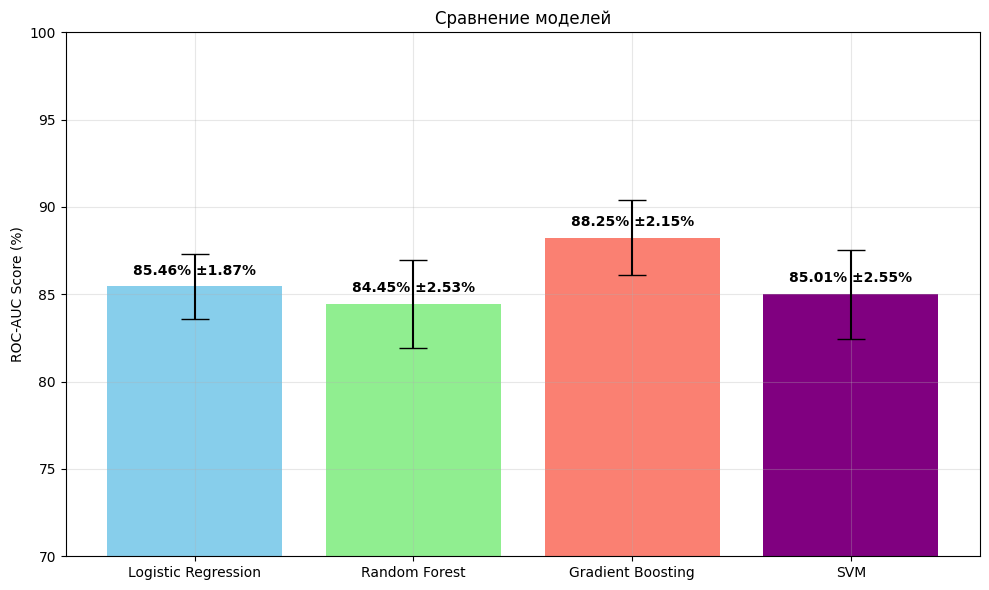

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(results.keys())
means = [results[name].mean() * 100 for name in model_names]
stds = [results[name].std() * 100 for name in model_names]

bars = ax.bar(model_names, means, yerr=stds, capsize=10, color=['skyblue', 'lightgreen', 'salmon', 'purple'])
ax.set_ylabel('ROC-AUC Score (%)')
ax.set_title('Сравнение моделей')
ax.set_ylim(70, 100)
ax.grid(True, alpha=0.3)

for bar, mean, std in zip(bars, means, stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{mean:.2f}% ±{std:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Вывод по сравнению моделей:** наибольшая точность (88.25%) была достигнута моделью Gradient Boosting, как и ожидалось. При этом std достаточно низкий (±2.1), модель стаблильная. Прочие модели тоже показали хорошие результаты, т.е. предобработка данных была выполнена качественно.

## Обучаем модель Gradient Boosting и проверяем ее на тестовой выборке

In [24]:
best_model = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("Метрики на тестовой выборке:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba)*100:.2f}%")

print("\nПодробный отчет:")
print(classification_report(y_test, y_pred, target_names=['Погиб (0)', 'Выжил (1)']))

Метрики на тестовой выборке:
Accuracy:  81.01%
Precision: 76.12%
Recall:    73.91%
F1-Score:  75.00%
ROC-AUC:   83.60%

Подробный отчет:
              precision    recall  f1-score   support

   Погиб (0)       0.84      0.85      0.85       110
   Выжил (1)       0.76      0.74      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



Сравним результаты с кросс-валидацией

In [38]:
print("Сравнение результатов:")
print(f"Кросс-валидация (ROC-AUC): 88.25% (±2.15%)")
print(f"Тестовая выборка (ROC-AUC): {roc_auc_score(y_test, y_pred_proba)*100:.2f}%")
print(f"Разница: {abs(88.25 - roc_auc_score(y_test, y_pred_proba)*100):.2f}%")

Сравнение результатов:
Кросс-валидация (ROC-AUC): 88.25% (±2.15%)
Тестовая выборка (ROC-AUC): 83.60%
Разница: 4.65%


Разница указывает на то, что модель, возможно, переобучена. Попробуем **подобрать гиперпараметры** для модели

In [37]:
best_model_tuned = GradientBoostingClassifier(
    random_state=42,
    n_estimators=75,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8
)

best_model_tuned.fit(X_train, y_train)
y_pred_tuned = best_model_tuned.predict(X_test)
y_pred_proba_tuned = best_model_tuned.predict_proba(X_test)[:, 1]

print("Результаты после подбора гиперпараметров:")
print(f"ROC-AUC на тесте: {roc_auc_score(y_test, y_pred_proba_tuned)*100:.2f}%")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_tuned)*100:.2f}%")

cv_scores_tuned = cross_val_score(best_model_tuned, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"\nКросс-валидация (tuned): {cv_scores_tuned.mean()*100:.2f}% (±{cv_scores_tuned.std()*100:.2f}%)")
print(f"Новая разница: {abs(cv_scores_tuned.mean()*100 - roc_auc_score(y_test, y_pred_proba_tuned)*100):.2f}%")

Результаты после подбора гиперпараметров:
ROC-AUC на тесте: 85.29%
Accuracy: 83.80%
F1-Score: 78.83%

Кросс-валидация (tuned): 87.97% (±2.31%)
Новая разница: 2.68%


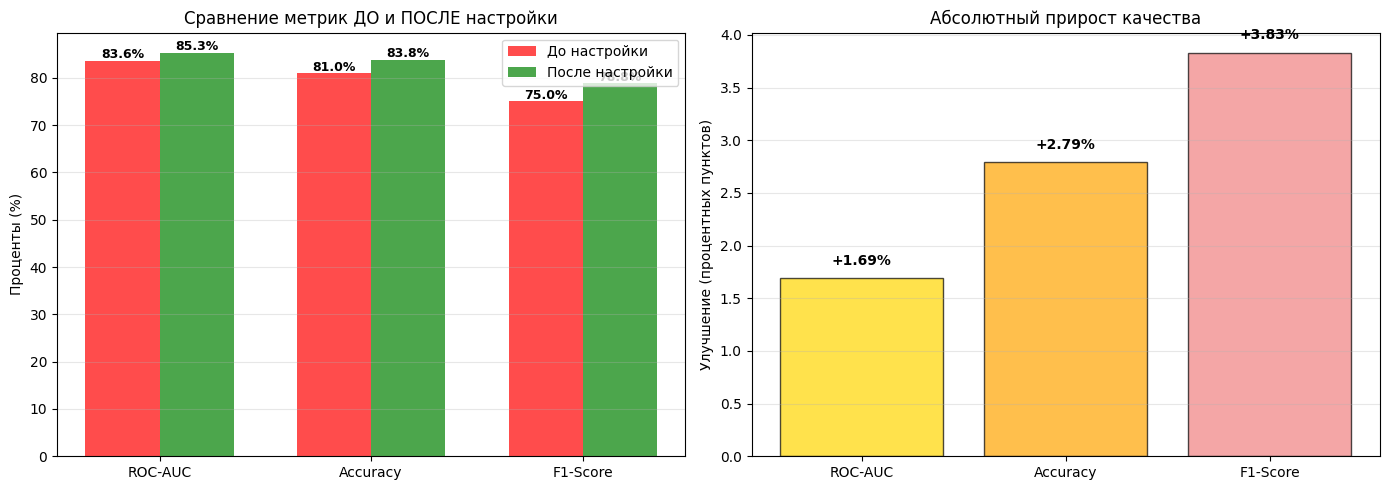

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение метрик
metrics = ['ROC-AUC', 'Accuracy', 'F1-Score']
before = [83.60, 81.01, 75.00]
after = [85.29, 83.80, 78.83]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, before, width, label='До настройки', color='red', alpha=0.7)
axes[0].bar(x + width/2, after, width, label='После настройки', color='green', alpha=0.7)
axes[0].set_ylabel('Проценты (%)')
axes[0].set_title('Сравнение метрик ДО и ПОСЛЕ настройки')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (b, a) in enumerate(zip(before, after)):
    axes[0].text(i - width/2, b + 0.5, f'{b:.1f}%', ha='center', fontweight='bold', fontsize=9)
    axes[0].text(i + width/2, a + 0.5, f'{a:.1f}%', ha='center', fontweight='bold', fontsize=9)

# График 2: Улучшение по каждой метрике
improvements = [85.29-83.60, 83.80-81.01, 78.83-75.00]
colors = ['gold', 'orange', 'lightcoral']

bars = axes[1].bar(metrics, improvements, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Улучшение (процентных пунктов)')
axes[1].set_title('Абсолютный прирост качества')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, imp in zip(bars, improvements):
    axes[1].text(bar.get_x() + bar.get_width()/2., imp + 0.1,
                f'+{imp:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

После подбора гиперпарпараметров модель стала более стабильной

## Визуализация результатов и анализ ошибок

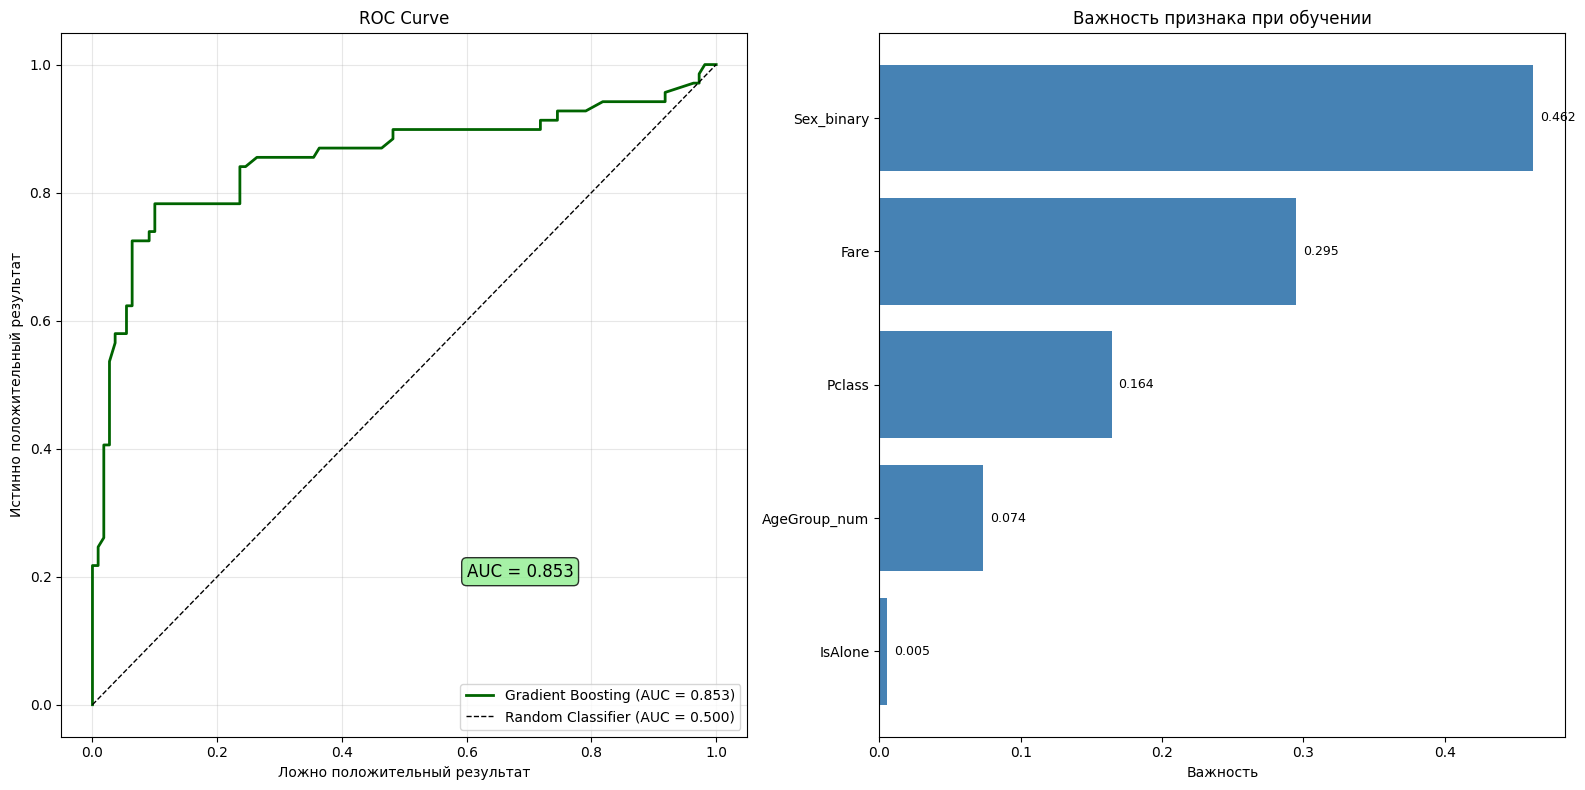

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_tuned)
auc = roc_auc_score(y_test, y_pred_proba_tuned)

axes[0].plot(fpr, tpr, label=f'Gradient Boosting (AUC = {auc:.3f})', linewidth=2, color='darkgreen')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)', linewidth=1)
axes[0].set_xlabel('Ложно положительный результат')
axes[0].set_ylabel('Истинно положительный результат')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.6, 0.2, f'AUC = {auc:.3f}', fontsize=12, 
             bbox=dict(boxstyle="round", facecolor='lightgreen', alpha=0.8))

if hasattr(best_model_tuned, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model_tuned.feature_importances_
    }).sort_values('importance', ascending=False)
    
    axes[1].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    axes[1].set_xlabel('Важность')
    axes[1].set_title('Важность признака при обучении')
    axes[1].invert_yaxis()
    
    for i, (idx, row) in enumerate(importance_df.iterrows()):
        axes[1].text(row['importance'] + 0.005, i, f'{row["importance"]:.3f}', 
                    va='center', fontsize=9)

plt.tight_layout()
plt.savefig('titanic_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
error_analysis = X_test.copy()

error_analysis['true_label'] = y_test
error_analysis['pred_label'] = y_pred_tuned
error_analysis['pred_proba'] = y_pred_proba_tuned
error_analysis['correct'] = y_test == y_pred_tuned

error_analysis['error_type'] = 'Correct'
error_analysis.loc[(y_test==1) & (y_pred_tuned==0), 'error_type'] = 'False Negative'
error_analysis.loc[(y_test==0) & (y_pred_tuned==1), 'error_type'] = 'False Positive'

print("\nРаспределение ошибок:")
print(error_analysis['error_type'].value_counts())
print(f"\nДоля правильных предсказаний: {(error_analysis['correct'].sum()/len(error_analysis))*100:.2f}%")

print("\nАнализ уверенности модели при ошибках:")
print(f"False Positives (ошибочно предсказано выживание):")
print(f"  Средняя вероятность выживания: {error_analysis[error_analysis['error_type']=='False Positive']['pred_proba'].mean():.3f}")

print(f"\nFalse Negatives (ошибочно предсказана смерть):")
print(f"  Средняя вероятность выживания: {error_analysis[error_analysis['error_type']=='False Negative']['pred_proba'].mean():.3f}")


Распределение ошибок:
error_type
Correct           150
False Negative     15
False Positive     14
Name: count, dtype: int64

Доля правильных предсказаний: 83.80%

Анализ уверенности модели при ошибках:
False Positives (ошибочно предсказано выживание):
  Средняя вероятность выживания: 0.654

False Negatives (ошибочно предсказана смерть):
  Средняя вероятность выживания: 0.158


## Сохраняем модель и скаляр

In [51]:
import joblib

joblib.dump(best_model_tuned, 'gradient_boosting_titanic.pkl')
joblib.dump(scaler, 'scaler_titanic.pkl')

['scaler_titanic.pkl']

## Выводы по обучению модели
Модель Gradient Boosting показала лучший результат среди всех алгоритмов с ROC-AUC 88.25% на кросс-валидации. После настройки гиперпараметров (уменьшение learning_rate до 0.05, ограничение глубины деревьев до 5, снижение n_estimators до 75) удалось сократить переобучение с 4.65% до 2.68%, а финальная точность на тестовой выборке достигла 83.80%  
Модель лучше предсказывает смерть (precision 84%, recall 85%), чем выживание (precision 76%, recall 74%), что объясняется дисбалансом классов в исходных данных. При этом ROC-AUC 85.29% подтверждает хорошую способность модели разделять классы, а результат соответствует уровню хороших решений на Kaggle.